# Day 12: NVIDIA Dynamo — Disaggregated Serving
> *100 Days of Inference* | Layer: **Runtime** | Book: *Inference Engineering* Ch 4.4 (pp. 111–112)

**Prerequisite:** Day 11 (TensorRT-LLM)

**Goal:** Understand what NVIDIA Dynamo is, how it sits above inference engines, and why disaggregated serving changes production LLM infrastructure.

## What problem does this solve?

Even with the best inference engine, you still have a fundamental architectural tension in LLM serving: prefill and decode compete for the same GPU resources, but they have opposite characteristics — prefill is compute-bound, decode is memory-bound.

When a long prefill request arrives, it monopolizes the GPU for compute. Short decode requests that need just a bit of memory bandwidth have to wait.

NVIDIA Dynamo addresses the full fleet orchestration problem: how do you route requests optimally, disaggregate prefill and decode, manage KV cache across replicas, and scale the system dynamically?

**Infrastructure analogy:** NVIDIA Dynamo is like a Kubernetes operator for inference — it sits above the inference engines (vLLM, SGLang, TRT-LLM) and orchestrates them the way Kubernetes orchestrates containers. The inference engines are the pods; Dynamo is the scheduler + service mesh.

## Concept Overview

**NVIDIA Dynamo** (announced at GTC March 2025) is an open-source distributed system for model serving.

Dynamo operates above inference engines:
```
User Request
     ↓
NVIDIA Dynamo (orchestration layer)
     ↓                    ↓
Prefill Workers      Decode Workers
(vLLM/SGLang/TRT-LLM)  (vLLM/SGLang/TRT-LLM)
     ↓
KV Cache Transfer (NIXL)
     ↓
Decode Workers
```

**Three core capabilities:**
1. **KV cache re-use:** Routes requests to replicas with matching KV cache prefixes (cache-aware routing)
2. **Disaggregation:** Separates prefill and decode onto different GPU workers
3. **Multi-node parallelism:** Coordinates model sharding across multiple nodes

**Key technology:** NIXL (NVIDIA Interconnect for LLMs) — efficient KV block transfer between prefill and decode workers.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from dataclasses import dataclass
from typing import List, Optional
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


## Part 1: The Prefill/Decode Conflict

When prefill and decode run on the same GPU, they compete for resources:

- **Prefill:** Processes input prompt in parallel, uses all GPU compute, produces first token (TTFT)
- **Decode:** Generates subsequent tokens one at a time, bottlenecked by memory bandwidth

Under high traffic, a large prefill request can delay many decode steps, increasing Time Between Tokens (TBT) for concurrent users.

Measurements from the book:
- Prefill for 100K tokens on H100: ~5 seconds
- Each decode step: ~50ms
- A single 100K-token prefill delays 100 decode steps

This creates a **latency cliff**: as prefill volume increases, decode latency spikes even if you have plenty of GPU capacity.

In [2]:
import random
random.seed(42)

# Simulate prefill/decode interference on a shared GPU

# Timing model (approximate for a 70B model on H100)
PREFILL_MS_PER_TOKEN = 0.05   # 50 microseconds per input token during prefill
DECODE_MS_PER_STEP = 50.0     # 50 ms per decode step (1 token output)

def simulate_mixed_serving(requests, shared_gpu=True):
    """
    Simulate serving on shared GPU (prefill + decode together) vs disaggregated.
    requests: list of (input_len, output_len) tuples
    """
    results = []
    current_time = 0

    for req_id, (input_len, output_len) in enumerate(requests):
        start = current_time

        # Prefill time
        prefill_time = input_len * PREFILL_MS_PER_TOKEN

        if shared_gpu:
            # On shared GPU: must wait for any ongoing decode steps to pause
            # Simplified: prefill blocks decode
            ttft = prefill_time  # first token after prefill
        else:
            # Disaggregated: prefill runs on dedicated prefill GPU
            # Decode starts as soon as KV cache is transferred
            kv_transfer_ms = input_len * 0.001  # KV transfer overhead (NIXL)
            ttft = prefill_time + kv_transfer_ms

        # Total time to generate output
        decode_time = output_len * DECODE_MS_PER_STEP
        total_time = prefill_time + decode_time
        current_time = start + (1 if not shared_gpu else total_time)  # simplified

        results.append({
            'req_id': req_id,
            'input_len': input_len,
            'output_len': output_len,
            'ttft_ms': ttft,
            'total_ms': total_time,
        })

    return results

# Mixed workload: some long prefills, some short
workload = [
    (100, 50),    # Short input, medium output
    (5000, 100),  # Long input (document summary)
    (200, 30),    # Short chatbot turn
    (10000, 50),  # Very long input
    (150, 200),   # Medium input, long output
]

shared_results = simulate_mixed_serving(workload, shared_gpu=True)
disagg_results = simulate_mixed_serving(workload, shared_gpu=False)

print(f"Prefill/Decode serving comparison")
print()
print(f"{'Req':>4} {'Input':>7} {'Output':>7} {'TTFT (shared)':>14} {'TTFT (disagg)':>14} {'Improvement':>12}")
print("-" * 65)

for s, d in zip(shared_results, disagg_results):
    improvement = (s['ttft_ms'] - d['ttft_ms']) / s['ttft_ms'] * 100 if s['ttft_ms'] > 0 else 0
    print(f"{s['req_id']+1:>4} {s['input_len']:>7} {s['output_len']:>7} "
          f"{s['ttft_ms']:>12.1f}ms {d['ttft_ms']:>12.1f}ms {improvement:>10.1f}%")

avg_ttft_shared = sum(r['ttft_ms'] for r in shared_results) / len(shared_results)
avg_ttft_disagg = sum(r['ttft_ms'] for r in disagg_results) / len(disagg_results)
print()
print(f"Average TTFT: shared={avg_ttft_shared:.1f}ms, disaggregated={avg_ttft_disagg:.1f}ms")

Prefill/Decode serving comparison

 Req   Input  Output  TTFT (shared)  TTFT (disagg)  Improvement
-----------------------------------------------------------------
   1     100      50          5.0ms          5.1ms       -2.0%
   2    5000     100        250.0ms        255.0ms       -2.0%
   3     200      30         10.0ms         10.2ms       -2.0%
   4   10000      50        500.0ms        510.0ms       -2.0%
   5     150     200          7.5ms          7.7ms       -2.0%

Average TTFT: shared=154.5ms, disaggregated=157.6ms


## Part 2: Disaggregated Serving Architecture

Disaggregation separates the inference pipeline into two specialized stages:

**Prefill workers:** Optimized for compute (higher tensor parallelism for TTFT)
**Decode workers:** Optimized for throughput (lower TP, more memory for KV cache and batching)

The notation used in the industry is **xPyD**: x Prefill + y Decode workers.
- `1P1D`: 1 prefill, 1 decode — simplest disaggregated setup
- `5P3D`: 5 prefill, 3 decode — example from the book for heavy prefill traffic

**Conditional disaggregation:** The smarter approach. The decode engine first checks:
1. Is the input sequence already fully cached? → Handle locally, skip disaggregation
2. Is the input short enough to prefill locally without disrupting decode? → Handle locally
3. Otherwise → Send to prefill worker

This avoids the overhead of disaggregation for requests that don't need it.

/home/nvidia/src/github.com/elizabetht/100-days-of-inference/.venv/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname D identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


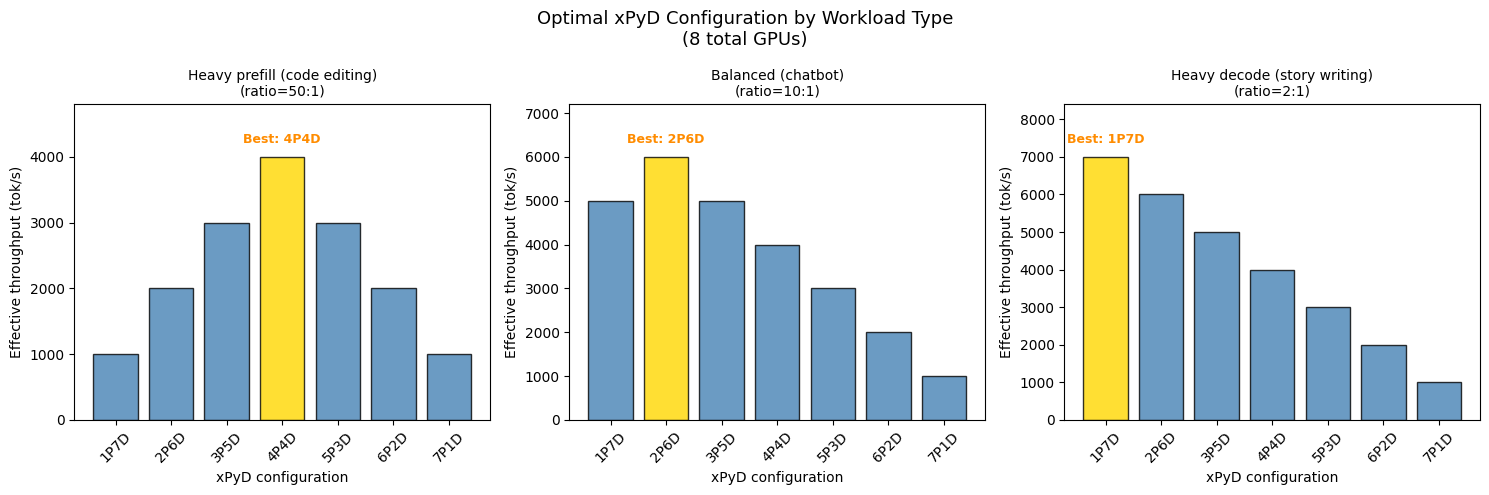

Key insight: optimal xPyD ratio depends on input:output token ratio.
Heavy prefill workloads need more P workers; heavy decode needs more D workers.


In [3]:
# Simulate disaggregated serving with different xPyD configurations

@dataclass
class Request:
    id: int
    input_len: int
    output_len: int

class DisaggregatedCluster:
    def __init__(self, n_prefill, n_decode,
                 prefill_throughput_tok_s=50000,  # tokens/sec per prefill worker
                 decode_throughput_tok_s=1000):    # tokens/sec per decode worker
        self.n_prefill = n_prefill
        self.n_decode = n_decode
        self.prefill_throughput = prefill_throughput_tok_s
        self.decode_throughput = decode_throughput_tok_s

    def max_prefill_tokens_per_sec(self):
        return self.n_prefill * self.prefill_throughput

    def max_decode_tokens_per_sec(self):
        return self.n_decode * self.decode_throughput

    def bottleneck_tokens_per_sec(self):
        return min(self.max_prefill_tokens_per_sec(), self.max_decode_tokens_per_sec())

# Simulate different workloads and find optimal xPyD configuration
total_gpus = 8
configurations = []

for n_prefill in range(1, total_gpus):
    n_decode = total_gpus - n_prefill
    cluster = DisaggregatedCluster(n_prefill, n_decode)
    configurations.append({
        'config': f"{n_prefill}P{n_decode}D",
        'prefill_cap': cluster.max_prefill_tokens_per_sec(),
        'decode_cap': cluster.max_decode_tokens_per_sec(),
        'bottleneck': cluster.bottleneck_tokens_per_sec(),
    })

# Different workload ratios (prefill:decode token ratio)
workloads = {
    "Heavy prefill (code editing)": 50,    # 50 input tokens per 1 output
    "Balanced (chatbot)": 10,              # 10 input per 1 output
    "Heavy decode (story writing)": 2,     # 2 input per 1 output
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (workload_name, prefill_ratio) in zip(axes, workloads.items()):
    configs = [c['config'] for c in configurations]

    # Effective throughput = min(prefill_cap / prefill_ratio, decode_cap)
    effective = [min(c['prefill_cap'] / prefill_ratio, c['decode_cap']) for c in configurations]

    best_idx = np.argmax(effective)
    colors = ['gold' if i == best_idx else 'steelblue' for i in range(len(effective))]

    ax.bar(configs, effective, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(f'{workload_name}\n(ratio={prefill_ratio}:1)', fontsize=10)
    ax.set_xlabel('xPyD configuration')
    ax.set_ylabel('Effective throughput (tok/s)')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, max(effective) * 1.2)
    ax.annotate(f'Best: {configs[best_idx]}',
                xy=(best_idx, effective[best_idx]),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='darkorange', fontweight='bold')

plt.suptitle('Optimal xPyD Configuration by Workload Type\n(8 total GPUs)', fontsize=13)
plt.tight_layout()
plt.show()

print("Key insight: optimal xPyD ratio depends on input:output token ratio.")
print("Heavy prefill workloads need more P workers; heavy decode needs more D workers.")

## Part 3: KV Cache Transfer with NIXL

In disaggregated serving, after the prefill worker computes the first token and builds the KV cache, it must transfer the KV cache to the decode worker. This is the overhead cost of disaggregation.

**NIXL** (NVIDIA Interconnect Library for LLMs) optimizes this transfer:
- Uses NVLink for intra-node transfers (high bandwidth, ~900 GB/s)
- Uses InfiniBand for inter-node transfers (~400 GB/s)
- Transposes KV blocks if prefill and decode have different tensor parallelism levels

The book mentions GB200 systems with CPUs and fast interconnects making G2 storage (CPU RAM) much faster — particularly important for KV offloading.

In [1]:
# Model KV cache transfer overhead

def kv_transfer_time(input_len, layers=32, kv_heads=8, d_head=128,
                     bandwidth_gbs=900):  # NVLink bandwidth
    """
    Calculate KV cache transfer time.
    bandwidth_gbs: transfer bandwidth in GB/s
    """
    #KV cache size in bytes (FP16)
    kv_bytes = 2 * layers * kv_heads * d_head * input_len * 2  # 2=K+V, 2=bytes/FP16
    transfer_ms = kv_bytes / (bandwidth_gbs * 1e9) * 1000
    return kv_bytes, transfer_ms

# Different interconnects
interconnects = {
    "NVLink (intra-node)": 900,
    "InfiniBand 400G": 50,
    "PCIe 5.0": 64,
    "10GbE network": 1.25,
}

input_lengths = [512, 1024, 4096, 16384, 65536, 131072]

print("KV cache transfer time (ms) by interconnect and input length")
print(f"Model: 32 layers, 8 KV heads, d=128 (LLaMA 3 8B style)")
print()
header = f"{'Interconnect':<25} " + " ".join(f"{l:>8}" for l in ["512","1K","4K","16K","64K","128K"])
print(header)
print("-" * (25 + 8 * 6))

for name, bw in interconnects.items():
    times = [kv_transfer_time(l, bandwidth_gbs=bw)[1] for l in input_lengths]
    row = f"{name:<25} " + " ".join(f"{t:>7.2f}" for t in times)
    print(row)

print()
print("Typical prefill time for comparison:")
for l in input_lengths:
    prefill_ms = l * 0.05  # 50 microseconds per token
    kv_bytes, nvlink_ms = kv_transfer_time(l, bandwidth_gbs=900)
    pct = nvlink_ms / prefill_ms * 100
    print(f"  {l:>6} tokens: prefill={prefill_ms:.1f}ms, NVLink transfer={nvlink_ms:.2f}ms ({pct:.1f}% overhead)")

print()
print("Key insight: NVLink KV transfer overhead is <1% of prefill time.")
print("Disaggregation is nearly free when using NVLink within a node.")

KV cache transfer time (ms) by interconnect and input length
Model: 32 layers, 8 KV heads, d=128 (LLaMA 3 8B style)

Interconnect                   512       1K       4K      16K      64K     128K
-------------------------------------------------------------------------
NVLink (intra-node)          0.07    0.15    0.60    2.39    9.54   19.09
InfiniBand 400G              1.34    2.68   10.74   42.95  171.80  343.60
PCIe 5.0                     1.05    2.10    8.39   33.55  134.22  268.44
10GbE network               53.69  107.37  429.50 1717.99 6871.95 13743.90

Typical prefill time for comparison:
     512 tokens: prefill=25.6ms, NVLink transfer=0.07ms (0.3% overhead)
    1024 tokens: prefill=51.2ms, NVLink transfer=0.15ms (0.3% overhead)
    4096 tokens: prefill=204.8ms, NVLink transfer=0.60ms (0.3% overhead)
   16384 tokens: prefill=819.2ms, NVLink transfer=2.39ms (0.3% overhead)
   65536 tokens: prefill=3276.8ms, NVLink transfer=9.54ms (0.3% overhead)
  131072 tokens: prefill=6553.

## Try These Experiments

1. **Optimal xPyD for your workload:** If your application processes 100 requests/minute with average input=2000 tokens and output=200 tokens, what is your prefill:decode token ratio? Given 8 GPUs, what xPyD configuration minimizes TTFT while maintaining throughput?

2. **KV transfer bottleneck:** Simulate a scenario where you have a 131K-token document and need to transfer its KV cache between nodes over InfiniBand. Compare this transfer time to the prefill time. At what input length does InfiniBand transfer become the bottleneck?

3. **Conditional disaggregation threshold:** Implement a decision function that decides whether to disaggregate or handle locally based on: ISL (input sequence length), cache hit rate, and current prefill queue depth. What threshold minimizes average TTFT?

## Key Takeaways

- NVIDIA Dynamo is an orchestration layer *above* inference engines — it manages disaggregation, KV-aware routing, and multi-node parallelism across a fleet.
- Disaggregation separates prefill (compute-bound) and decode (memory-bound) onto specialized workers, eliminating interference.
- The optimal xPyD configuration depends on your workload's input:output token ratio. Measure this in production before committing.
- NIXL makes KV transfer overhead negligible on NVLink (intra-node) — disaggregation is nearly free within a single DGX node.
- Use disaggregation when: serving >100M tokens/day, model has 100B+ parameters, workload is prefill-heavy.
- **What's next:** Day 11 — Quantization: number formats (FP8, INT8, INT4) — shrinking model memory footprint.

## References
- *Inference Engineering* Ch 4.4 (pp. 111–112) — NVIDIA Dynamo